<a href="https://colab.research.google.com/github/Loopinlogix/IMDB/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upgrade relevant libraries to address potential import compatibility issues
!pip install --upgrade transformers datasets torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 829.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1

In [2]:
#Github
!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"


!git clone https://github.com/Loopinlogix/IMDB.git
%cd IMDB
!ls


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Cloning into 'IMDB'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 354.17 KiB | 2.44 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/IMDB/IMDB
'Customer Sentiment IMDB.ipynb'   README.md


In [3]:
import json

def fix_notebook(path_in, path_out=None):
    # If no output path is given, overwrite the original file
    if path_out is None:
        path_out = path_in

    with open(path_in, "r", encoding="utf-8") as f:
        nb = json.load(f)

    metadata = nb.get("metadata", {})

    # Fix or remove metadata.widgets
    if "widgets" in metadata:
        widgets = metadata["widgets"]

        # Case 1: widgets is not a dict → remove it
        if not isinstance(widgets, dict):
            print("Removing corrupted metadata.widgets (not a dict)...")
            metadata.pop("widgets", None)

        else:
            # Case 2: widgets exists but 'state' is missing → add it
            if "state" not in widgets:
                print("Adding missing 'state' key to metadata.widgets...")
                widgets["state"] = {}

            # Case 3: widgets['state'] exists but is invalid → remove widgets entirely
            elif not isinstance(widgets["state"], dict):
                print("Removing corrupted metadata.widgets (invalid state)...")
                metadata.pop("widgets", None)

        nb["metadata"] = metadata

    # Save the fixed notebook
    with open(path_out, "w", encoding="utf-8") as f:
        json.dump(nb, f, indent=2)

    print(f"Notebook fixed and saved to: {path_out}")

  SENTIMENT ANALYSIS - IMDB MOVIE REVIEWS

Dataset loaded successfully!
Shape: (50000, 2)
Columns: ['review', 'sentiment']

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing values:
review       0
sentiment    0
dtype: int64

STEP 2: EXPLORATORY DATA ANALYSIS

Sentiment Distribution:
sentiment
positive    25000
negative    2

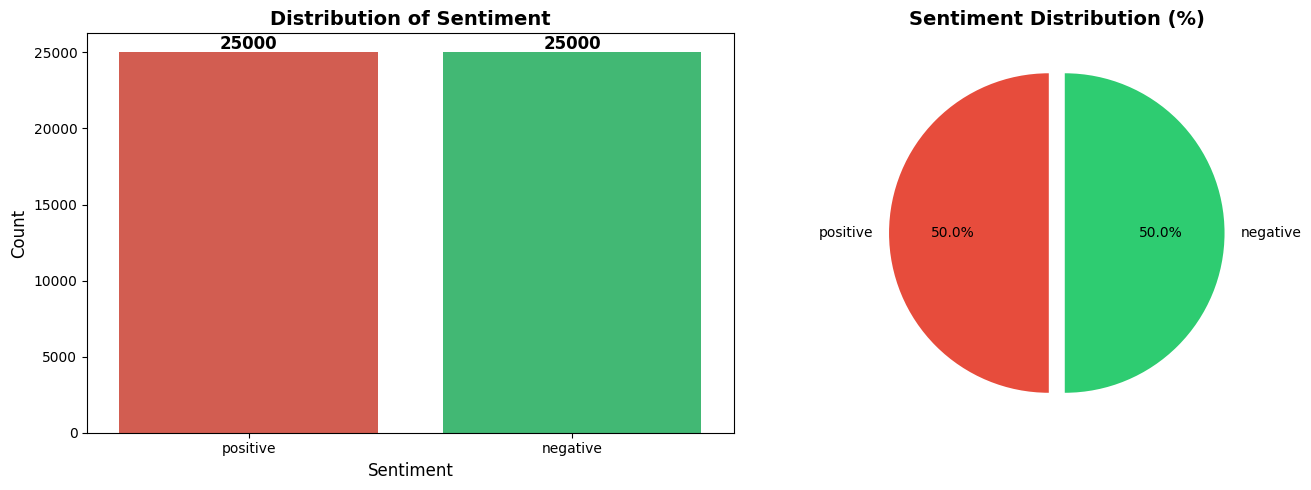


EDA visualization saved!

STEP 3: TEXT PREPROCESSING

Sample raw review (before cleaning):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru...

Cleaning text data...

Sample cleaned review (after cleaning):
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a...

Empty reviews after cleaning: 0

Average review length: 1240.9 characters
Min review length: 30
Max review length: 13271

Text preprocessing completed!

STEP 4: FEATURE ENGINEERING - VECTORIZATION

Using subset of 1000 samples for fast

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generating BERT embeddings...
BERT embedding matrix shape: (100, 768)

Applying t-SNE...

Applying t-SNE...
t-SNE output shape: (100, 2)


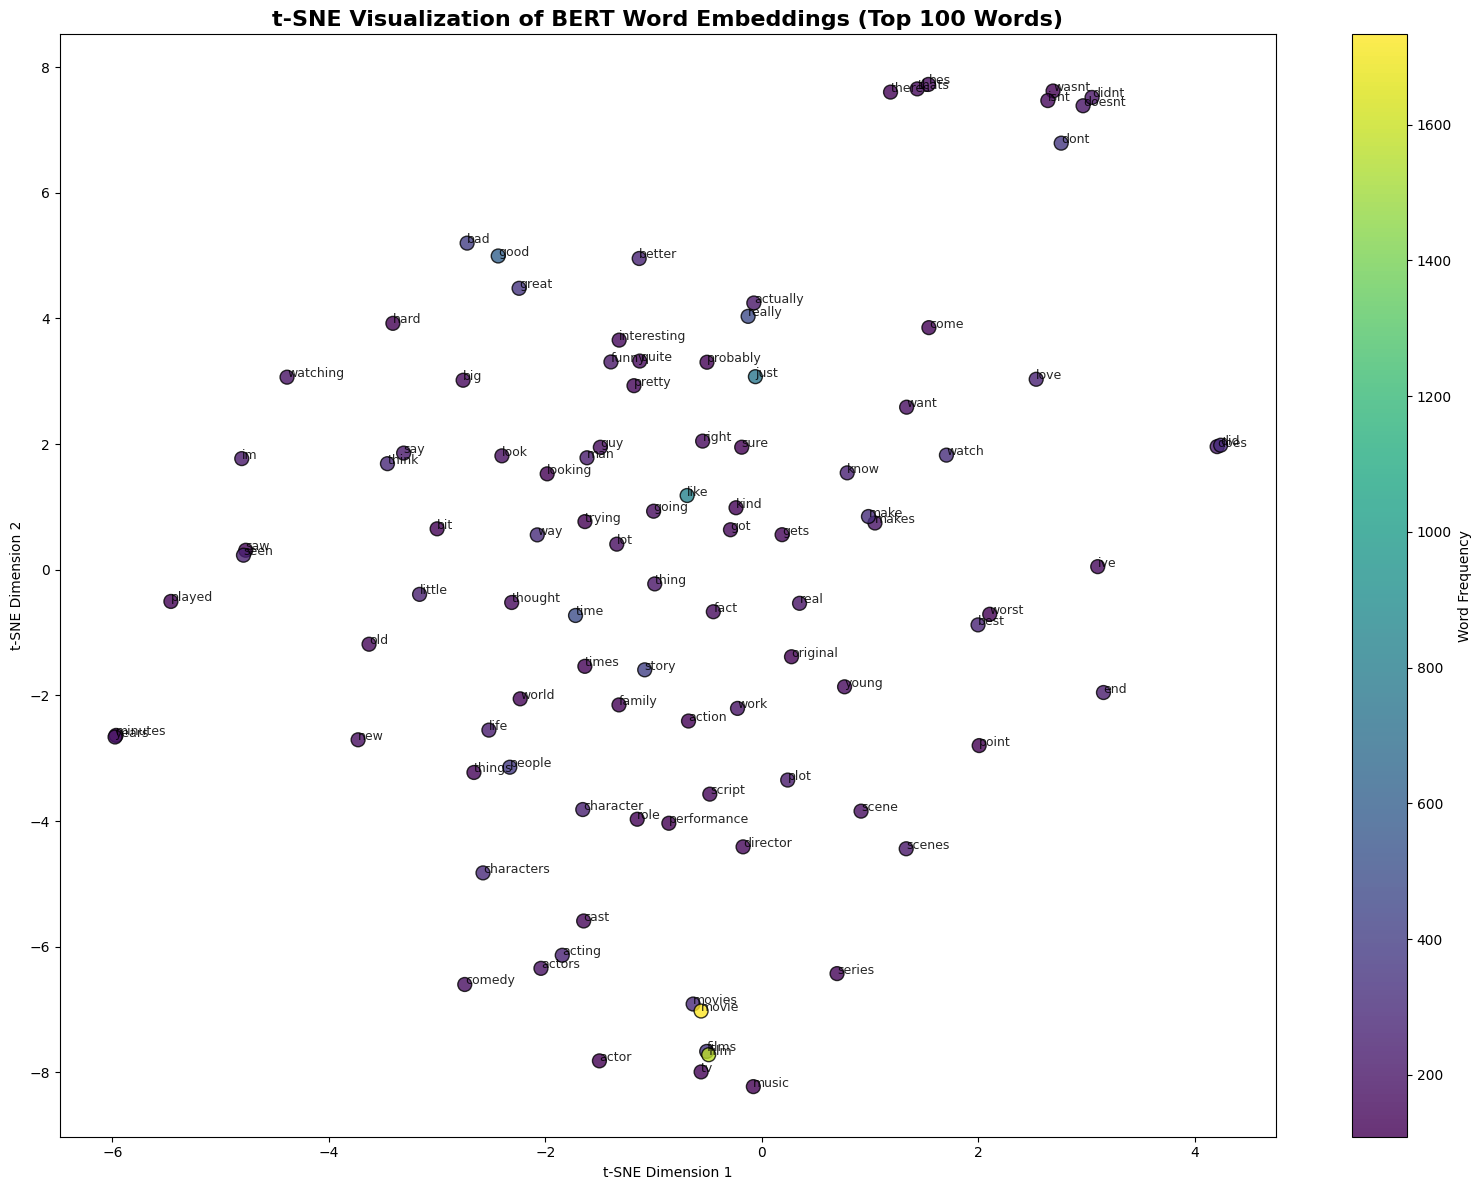


BERT word embeddings visualization completed!

STEP 6: TRAIN-TEST SPLIT & TRADITIONAL ML MODELS (FAST)
Training set size: 800
Test set size: 200
Training label distribution: {0: 419, 1: 381}
Test label distribution: {0: 105, 1: 95}

--- Training Logistic Regression (FAST) ---

--- Logistic Regression (TF-IDF) ---
Accuracy:  0.7900
Precision: 0.8046
Recall:    0.7368
F1-Score:  0.7692
ROC-AUC:   0.8966

--- Training FAST SVM (Linear Kernel) ---

--- SVM (Linear Kernel) (TF-IDF) ---
Accuracy:  0.8350
Precision: 0.8444
Recall:    0.8000
F1-Score:  0.8216
ROC-AUC:   0.9093

--- Training Naive Bayes ---

--- Naive Bayes (Bag of Words) ---
Accuracy:  0.8200
Precision: 0.8734
Recall:    0.7263
F1-Score:  0.7931
ROC-AUC:   0.8867

--- Training Random Forest (FAST) ---

--- Random Forest (TF-IDF) ---
Accuracy:  0.7900
Precision: 0.8354
Recall:    0.6947
F1-Score:  0.7586
ROC-AUC:   0.8880

All fast models trained!

STEP 7: MODEL EVALUATION & VISUALIZATION

Model Comparison Table:
             

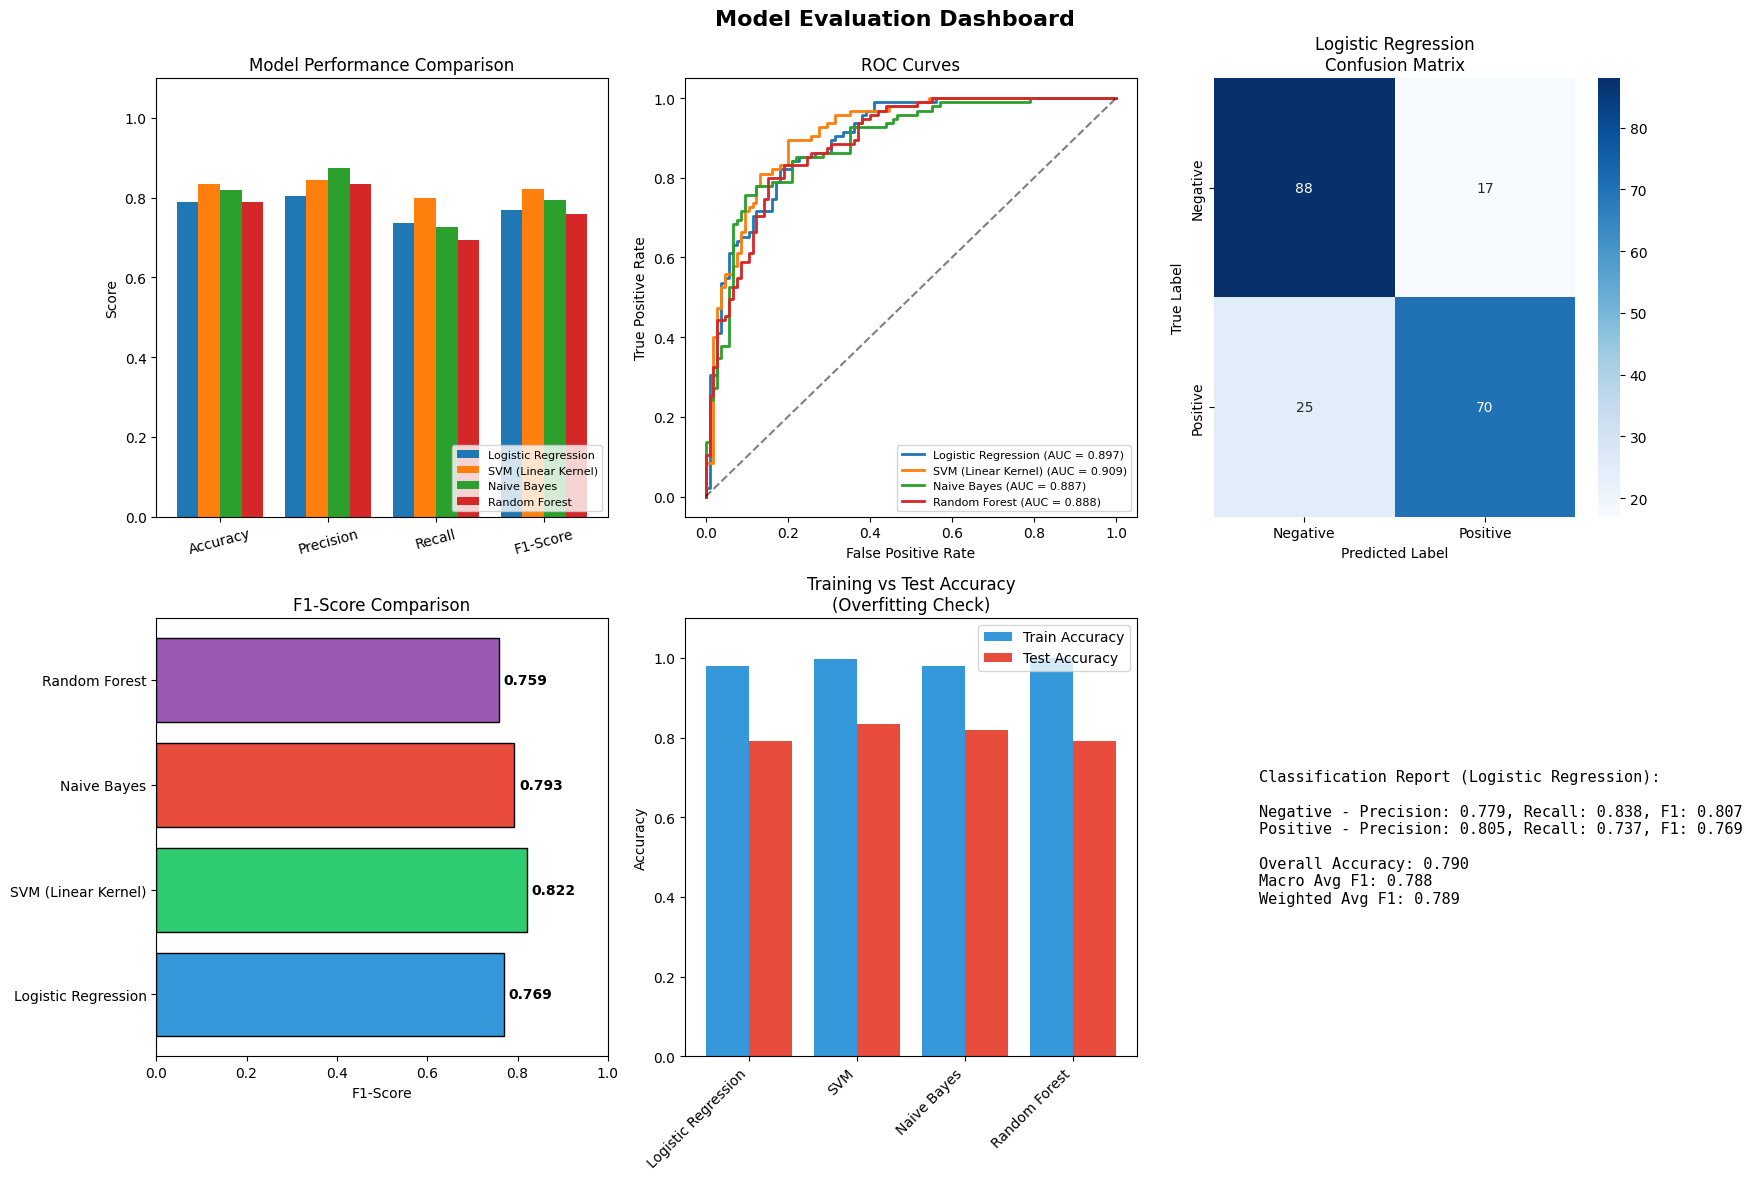


Model evaluation visualization completed!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')
from sklearn.manifold import TSNE
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer



# Scikit-learn imports
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

print("=" * 60)
print("  SENTIMENT ANALYSIS - IMDB MOVIE REVIEWS")
print("=" * 60)

# Load the dataset
df = pd.read_csv("/content/IMDB Dataset.csv")

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS & VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Check class distribution
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nPositive: {df['sentiment'].value_counts()['positive'] / len(df) * 100:.1f}%")
print(f"Negative: {df['sentiment'].value_counts()['negative'] / len(df) * 100:.1f}%")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment Distribution (Count Plot)
sns.countplot(data=df, x='sentiment', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution of Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(df['sentiment'].value_counts()):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=12)

# Plot 2: Sentiment Distribution (Pie Chart)
colors = ['#e74c3c', '#2ecc71']
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nEDA visualization saved!")


# ============================================================
# STEP 3: TEXT PREPROCESSING
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: TEXT PREPROCESSING")
print("=" * 60)

# Sample raw review before preprocessing
print("\nSample raw review (before cleaning):")
print(df['review'].iloc[0][:300] + "...")

# Text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data:
    1. Remove HTML tags
    2. Remove special characters and punctuation
    3. Convert to lowercase
    4. Remove extra whitespace
    """
    # Remove HTML tags
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters and digits, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing to all reviews
print("\nCleaning text data...")
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Show sample after preprocessing
print("\nSample cleaned review (after cleaning):")
print(df['cleaned_review'].iloc[0][:300] + "...")

# Check for empty reviews after cleaning
empty_reviews = df[df['cleaned_review'].str.len() == 0]
print(f"\nEmpty reviews after cleaning: {len(empty_reviews)}")

# Remove any empty reviews if they exist
if len(empty_reviews) > 0:
    df = df[df['cleaned_review'].str.len() > 0].reset_index(drop=True)
    print(f"Dataset shape after removing empty reviews: {df.shape}")

# Add review length as a feature
df['review_length'] = df['cleaned_review'].apply(len)
print(f"\nAverage review length: {df['review_length'].mean():.1f} characters")
print(f"Min review length: {df['review_length'].min()}")
print(f"Max review length: {df['review_length'].max()}")

print("\nText preprocessing completed!")

# ============================================================
# STEP 4: FEATURE ENGINEERING - VECTORIZATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: FEATURE ENGINEERING - VECTORIZATION")
print("=" * 60)

# For faster training, use a subset of data (e.g., 10,000 samples)
# In production, use full dataset
SAMPLE_SIZE = 1000
print(f"\nUsing subset of {SAMPLE_SIZE} samples for faster training...")
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Encode labels: positive=1, negative=0
df_sample['label'] = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

X = df_sample['cleaned_review']
y = df_sample['label']

print(f"Dataset shape: {df_sample.shape}")
print(f"Label distribution: {y.value_counts().to_dict()}")

# 4.1 Bag of Words (CountVectorizer)
print("\n--- 4.1 Creating Bag of Words vectors ---")
count_vectorizer = CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_bow = count_vectorizer.fit_transform(X)
print(f"Bag of Words shape: {X_bow.shape}")
print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")

# 4.2 TF-IDF Vectorization
print("\n--- 4.2 Creating TF-IDF vectors ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(X)
print(f"TF-IDF shape: {X_tfidf.shape}")

# 4.3 Show top features for TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample TF-IDF features: {feature_names[:20]}")

print("\nVectorization completed!")

# ============================================================
# STEP 5: WORD EMBEDDINGS VISUALIZATION (BERT + t-SNE)
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: WORD EMBEDDINGS VISUALIZATION (BERT)")
print("=" * 60)

from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.manifold import TSNE

# Select top 100 most frequent words
top_n = 100
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
top_indices = np.argsort(word_counts)[-top_n:]
top_words = [feature_names[i] for i in top_indices]

print(f"\nTop {top_n} words selected for embedding visualization.")
print("Example words:", top_words[:10])

# ------------------------------------------------------------
# Load BERT model
# ------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

# ------------------------------------------------------------
# Function to compute BERT embedding for a word
# ------------------------------------------------------------
def get_embedding(word):
    inputs = tokenizer(word, return_tensors="pt")
    outputs = model(**inputs)
    # Mean pooling over token embeddings \u2192 768\u2011dim vector
    embedding = outputs.last_hidden_state.mean(dim=1).detach().numpy().flatten()
    return embedding

# ------------------------------------------------------------
# Generate embeddings for each top word
# ------------------------------------------------------------
print("\nGenerating BERT embeddings...")
bert_vectors = np.vstack([get_embedding(word) for word in top_words])

print("BERT embedding matrix shape:", bert_vectors.shape)
# Expected: (100, 768)

# ------------------------------------------------------------
# Apply t\u2011SNE to reduce 768 \u2192 2 dimensions
# ------------------------------------------------------------
print("\nApplying t-SNE...")
print("\nApplying t-SNE...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

word_embeddings_2d = tsne.fit_transform(bert_vectors)
print("t-SNE output shape:", word_embeddings_2d.shape)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(16, 12))
plt.scatter(
    word_embeddings_2d[:, 0],
    word_embeddings_2d[:, 1],
    c=word_counts[top_indices],
    cmap='viridis',
    s=100,
    alpha=0.8,
    edgecolors='black'
)

# Annotate each word
for i, word in enumerate(top_words):
    plt.annotate(word,
                 (word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]),
                 fontsize=9,
                 alpha=0.85)

plt.colorbar(label='Word Frequency')
plt.title('t-SNE Visualization of BERT Word Embeddings (Top 100 Words)',
          fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

print("\nBERT word embeddings visualization completed!")

# ============================================================
# STEP 6: TRAIN-TEST SPLIT & TRADITIONAL ML MODELS (FAST VERSION)
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: TRAIN-TEST SPLIT & TRADITIONAL ML MODELS (FAST)")
print("=" * 60)

# Split data (80% train, 20% test)
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train_bow.shape[0]}")
print(f"Test set size: {X_test_bow.shape[0]}")
print(f"Training label distribution: {y_train.value_counts().to_dict()}")
print(f"Test label distribution: {y_test.value_counts().to_dict()}")

# Dictionary to store all results
all_results = {}

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name, vectorizer_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    results = {
        'model_name': model_name,
        'vectorizer': vectorizer_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    if y_proba is not None:
        results['roc_auc'] = roc_auc_score(y_test, y_proba)

    print(f"\n--- {model_name} ({vectorizer_name}) ---")
    print(f"Accuracy:  {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall:    {results['recall']:.4f}")
    print(f"F1-Score:  {results['f1']:.4f}")
    if 'roc_auc' in results:
        print(f"ROC-AUC:   {results['roc_auc']:.4f}")

    return results

# ------------------------------------------------------------
# 6.1 Logistic Regression (FAST)
# ------------------------------------------------------------
print("\n--- Training Logistic Regression (FAST) ---")

lr_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

all_results['Logistic Regression'] = evaluate_model(
    lr_model, X_test_tfidf, y_test, 'Logistic Regression', 'TF-IDF'
)

# ------------------------------------------------------------
# 6.2 FAST SVM (Linear Kernel)
# ------------------------------------------------------------
print("\n--- Training FAST SVM (Linear Kernel) ---")

from sklearn.svm import SVC

svm_fast = SVC(
    kernel='linear',
    C=1.0,
    probability=True,   # still gives ROC curves
    random_state=42
)

svm_fast.fit(X_train_tfidf, y_train)

all_results['SVM (Linear Kernel)'] = evaluate_model(
    svm_fast, X_test_tfidf, y_test, 'SVM (Linear Kernel)', 'TF-IDF'
)

# ------------------------------------------------------------
# 6.3 Naive Bayes (BoW)
# ------------------------------------------------------------
print("\n--- Training Naive Bayes ---")

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

all_results['Naive Bayes'] = evaluate_model(
    nb_model, X_test_bow, y_test, 'Naive Bayes', 'Bag of Words'
)

# ------------------------------------------------------------
# 6.4 Random Forest (FAST)
# ------------------------------------------------------------
print("\n--- Training Random Forest (FAST) ---")

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

all_results['Random Forest'] = evaluate_model(
    rf_model, X_test_tfidf, y_test, 'Random Forest', 'TF-IDF'
)

print("\nAll fast models trained!")


# ============================================================
# STEP 7: MODEL EVALUATION & VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: MODEL EVALUATION & VISUALIZATION")
print("=" * 60)

# Create comparison table
results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r.get('roc_auc', 'N/A')
    }
    for name, r in all_results.items()
])

print("\nModel Comparison Table:")
print(results_df.to_string(index=False))

# Create visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold')

# 1. Metrics Comparison Bar Chart
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=row['Model'])

ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metrics, rotation=15)
ax1.legend(loc='lower right', fontsize=8)
ax1.set_ylim(0, 1.1)

# 2. ROC Curves
ax2 = axes[0, 1]
for name, result in all_results.items():
    if result['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, linewidth=2,
                label=f"{name} (AUC = {roc_auc:.3f})")

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves')
ax2.legend(loc='lower right', fontsize=8)

# 3. Confusion Matrix for Best Model (Logistic Regression)
ax3 = axes[0, 2]
best_pred = all_results['Logistic Regression']['y_pred']
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax3.set_title('Logistic Regression\nConfusion Matrix')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# 4. F1-Score Comparison
ax4 = axes[1, 0]
f1_scores = [r['f1'] for r in all_results.values()]
model_names = list(all_results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax4.barh(model_names, f1_scores, color=colors, edgecolor='black')
ax4.set_xlabel('F1-Score')
ax4.set_title('F1-Score Comparison')
ax4.set_xlim(0, 1)
for i, v in enumerate(f1_scores):
    ax4.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# 5. Training vs Test Accuracy (check for overfitting)
ax5 = axes[1, 1]
train_scores = []
test_scores = []
model_labels = []

for name, model in [('Logistic Regression', lr_model),
                    ('SVM', svm_fast),
                    ('Naive Bayes', nb_model),
                    ('Random Forest', rf_model)]:
    if name == 'Naive Bayes':
        train_acc = accuracy_score(y_train, model.predict(X_train_bow))
        test_acc = accuracy_score(y_test, model.predict(X_test_bow))
    else:
        train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
        test_acc = accuracy_score(y_test, model.predict(X_test_tfidf))

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    model_labels.append(name)

x_pos = np.arange(len(model_labels))
ax5.bar(x_pos - 0.2, train_scores, 0.4, label='Train Accuracy', color='#3498db')
ax5.bar(x_pos + 0.2, test_scores, 0.4, label='Test Accuracy', color='#e74c3c')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(model_labels, rotation=45, ha='right')
ax5.set_ylabel('Accuracy')
ax5.set_title('Training vs Test Accuracy\n(Overfitting Check)')
ax5.legend()
ax5.set_ylim(0, 1.1)

# 6. Classification Report for Best Model
ax6 = axes[1, 2]
ax6.axis('off')
report = classification_report(y_test, best_pred,
                               target_names=['Negative', 'Positive'],
                               output_dict=True)
report_text = "Classification Report (Logistic Regression):\n\n"
report_text += f"Negative - Precision: {report['Negative']['precision']:.3f}, Recall: {report['Negative']['recall']:.3f}, F1: {report['Negative']['f1-score']:.3f}\n"
report_text += f"Positive - Precision: {report['Positive']['precision']:.3f}, Recall: {report['Positive']['recall']:.3f}, F1: {report['Positive']['f1-score']:.3f}\n"
report_text += f"\nOverall Accuracy: {report['accuracy']:.3f}\n"
report_text += f"Macro Avg F1: {report['macro avg']['f1-score']:.3f}\n"
report_text += f"Weighted Avg F1: {report['weighted avg']['f1-score']:.3f}"
ax6.text(0.1, 0.5, report_text, fontsize=11, verticalalignment='center',
         family='monospace', transform=ax6.transAxes)

plt.tight_layout()
plt.show()

print("\nModel evaluation visualization completed!")